# 用线性回归预测市场走势

普通最小二乘（OLS）与线性回归是沿用数十年的统计方法，已在许多领域证明有用。本节用线性回归做价格预测，先快速回顾基础，再介绍基本思路。

## 线性回归的理论基础

在正式应用之前，先用一组随机数据快速回顾线性回归会更清楚。示例先用 NumPy 生成自变量 x 的 ndarray；再据此生成因变量 y 的随机（带噪声）数据。NumPy 提供 `polyfit` 与 `polyval`，便于基于简单单项式做 OLS。线性回归时，单项式最高次数设为 1。

In [1]:
import os
import random
import numpy as np  # 导入 NumPy
from pylab import mpl, plt  # 导入 matplotlib
plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
os.environ['PYTHONHASHSEED'] = '0'

In [2]:
num = 50

def set_seeds(seed=100):
    random.seed(seed)
    np.random.seed(seed)

set_seeds()  # 固定相关随机数生成器的种子

In [3]:
x = np.linspace(0, 10, num)  # 在 0 到 10 之间生成均匀间隔的 x
x

array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])

In [4]:
y = x + np.random.standard_normal(num)  # 生成带噪声的 y
y

array([-1.74976547,  0.54676204,  1.56119907,  0.35980886,  1.79764732,
        1.534627  ,  1.44566947,  0.3585281 ,  1.44315723,  2.09173614,
        1.58278934,  2.68006145,  1.86538454,  3.4699083 ,  3.52986366,
        2.95681335,  2.73402575,  4.49912044,  3.23533377,  2.75923277,
        5.70061431,  5.82731946,  4.23791678,  3.85144181,  5.08247787,
        6.03912302,  6.03712279,  6.87176021,  5.38804766,  5.97404336,
        6.34484859,  4.88331362,  5.77425994,  7.55114789,  7.68922027,
        6.68691022,  8.53656104,  5.86040358,  6.39870299,  6.72674916,
        7.61882614,  7.6991752 ,  8.57874313,  8.16257147, 10.27933991,
        7.45057785,  8.404445  ,  9.94934449,  8.18233986, 11.47071387])

In [5]:
reg = np.polyfit(x, y, deg=1)  # 做 1 次 OLS（即线性回归）

In [6]:
reg  # 查看最优参数

array([0.94612934, 0.22855261])

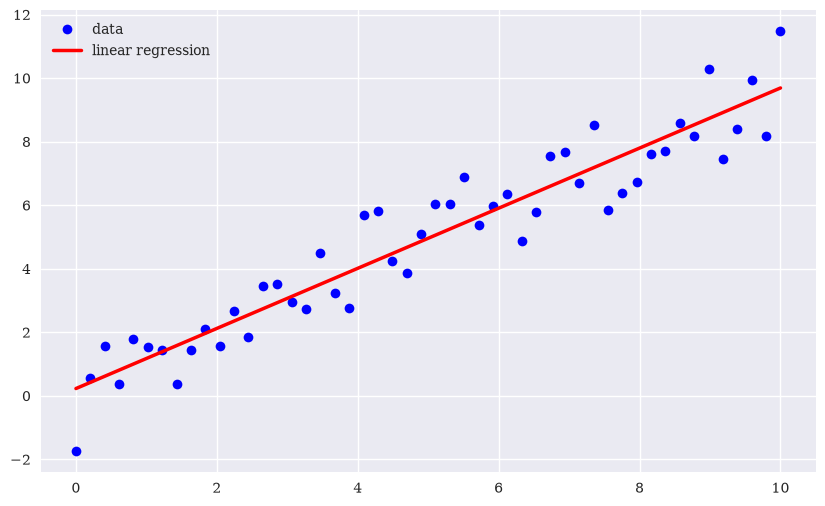

In [7]:
plt.figure(figsize=(10, 6))  # 新建图
plt.plot(x, y, 'bo', label='data')  # 用散点画原始数据
plt.plot(x, np.polyval(reg, x), 'r', lw=2.5,  # 画回归直线
         label='linear regression')
plt.legend(loc=0);  # 图例

*图 5-1. 基于随机数据的线性回归示意*

自变量 x 的区间是 $x \in [0, 10]$。若把区间扩大到例如 $x \in [0, 20]$，就可以用已估出的最优回归参数，对原始数据域之外的 y 做外推预测。

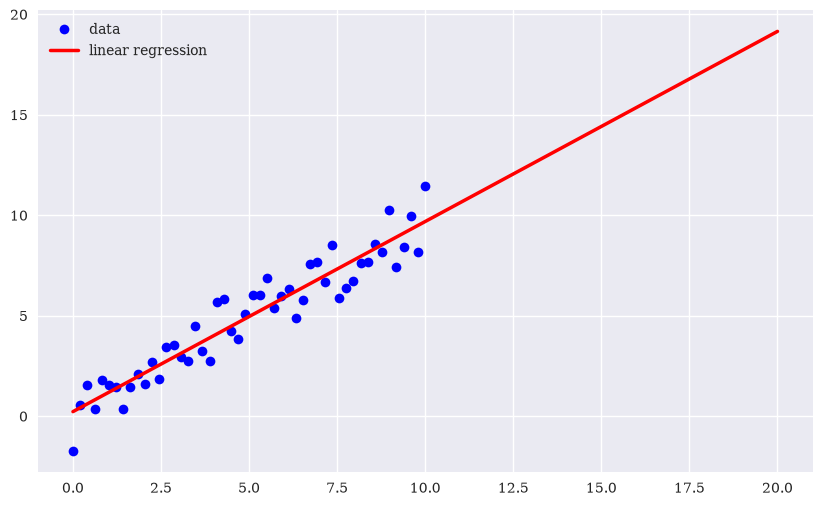

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'bo', label='data')
xn = np.linspace(0, 20, num)  # 扩大 x 的定义域
plt.plot(xn, np.polyval(reg, xn), 'r', lw=2.5, label='linear regression')
plt.legend(loc=0);

*图 5-2. 基于线性回归的预测（外推）*

## 价格预测的基本思路

用时间序列预测价格，有一点和平时的线性回归不一样：时间顺序很重要。

普通回归里，只要每一对 (x, y) 配对不变，把样本顺序打乱，估出来的参数通常不变。上一节第一个例子就是这样。

但要预测“明天的指数”，就不能乱序。你只能用“今天、昨天、前天……”这些已经发生的值，去猜还没发生的明天。用到过去几天，就叫滞后阶数（lags）。比如用今天、昨天、前天一共 3 天，就是三阶滞后。

下面用 0 到 11 这个极简序列说明。

In [9]:
x = np.arange(12)

In [10]:
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

假设用三阶滞后做回归，就是用过去 3 天预测下一天：3 个自变量，1 个因变量。

把序列 0, 1, 2, ..., 11 按时间往前滑，可以得到多组训练样本：

用 0, 1, 2 预测 3

用 1, 2, 3 预测 4

…

用 8, 9, 10 预测 11


一共 9 组。这不是一次性预测未来 9 个数,而是 9 组历史上 “前 3 天“ 预测 ”后 1 天” 的例子，用来拟合参数。9 组的样本数量算是一个能接受的值。

写成线性方程就是 A⋅x=b, 其中 A 是由这些自变量拼成的矩阵，b 是对应的目标值，x 是要求的回归参数。


In [11]:
lags = 3  # 定义滞后阶数

In [12]:
m = np.zeros((lags + 1, len(x) - lags))  # 按合适维度创建 ndarray

In [13]:
m[lags] = x[lags:]  # 定义目标值（因变量）
for i in range(lags):  # 遍历 0 到 lags-1
    m[i] = x[i:i - lags]  # 定义基向量（自变量）

In [14]:
m

array([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
       [ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.],
       [ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]])

自变量多于一个时，polyfit 和 polyval 就不够用了，这时要用 NumPy 线性代数子包 linalg 里的 lstsq 来做一般最小二乘。lstsq 会返回多项结果，取第一项就是最优回归参数：

In [15]:
A = m[:lags].T # A.T

In [16]:
b = m[lags] # b

In [17]:
x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None) # A @ x ≈ b

In [18]:
x # 最优回归参数

array([-0.66666667,  0.33333333,  1.33333333])

回归都在解同一个问题：找 $x$，让

$$
\|Ax - b\|^2
$$

尽量小。

对任意候选解 $x^*$，如果存在非零向量 $v$ 满足

$$
Av = 0
$$

（$v$ 在 $A$ 的零空间里），那么

$$
A(x^* + v) = Ax^* + Av = Ax^*
$$

所以 $x^*$ 和 $x^* + v$ 给出完全相同的拟合，残差也一样。于是：

- $\operatorname{rank}(A) = N$（列满秩）：零空间只有 $0$，最优 $x$ 唯一
- $\operatorname{rank}(A) < N$：存在非零 $v$，最优 $x$ 有无穷多个

你之前的三阶滞后玩具数据里，三列满足

$$
\mathrm{col}_2 - 2\cdot\mathrm{col}_1 + \mathrm{col}_0 = 0
$$

所以 $\operatorname{rank}=2 < 3$，解不唯一。`lstsq` 会在这些等价最优解里，再挑一个范数较小的（最小范数解）。

In [19]:
residuals # 残差平方和

array([], dtype=float64)

数学上，残差是有的，而且最小残差通常只有一个。

最小二乘求的是：找一个 $x$，让 $\|b - Ax\|^2$ 尽量小。矩阵不满秩时，能达到这个最小值的 $x$ 可以有很多个，解不唯一；但这个最小残差数值通常是唯一的。所以不是“不满秩就没有残差”，只是最优参数不唯一。

实现上，NumPy 在这种情况下懒得算给你看。`lstsq` 底层走 LAPACK：只有在“样本数多于参数个数，并且列满秩”时，QR 分解算完后残差平方和几乎是顺手得到的，才会填进 `residuals`。

一旦出现下面任一情况：

- $\operatorname{rank}(A) < N$（列线性相关）
- $M \le N$（样本不够多，或刚好方阵）

这条顺手路径就不适用了。NumPy 的约定是直接返回空数组，而不是再额外算一遍 $\|b - Ax\|^2$。

所以 `array([])` 的意思是：这项没有提供，需要时请自己算, 不是残差不存在，也不是残差不是 0。

In [20]:
residuals_real = np.sum((b - A @ x) ** 2)
residuals_real

np.float64(7.967495142732219e-29)

In [21]:
rank # 矩阵 A 的秩，看自变量是否线性相关、方程是否病态

np.int32(2)

序列是 0,1,2,...,11，等差、公差为 1。三阶滞后每一列只是把它平移一格：

col0: 0,1,2,...,8
col1: 1,2,3,...,9   = col0 + 1
col2: 2,3,4,...,10  = col0 + 2
所以对每个位置都有：

col2 - 2*col1 + col0
= (col0+2) - 2(col0+1) + col0
= 0
这就是等差数列的二阶差分恒为 0；三个滞后列必然线性相关，rank=2。

In [22]:
s # A 的奇异值，用来判断数值稳定性和有效秩

array([2.94834317e+01, 1.93060965e+00, 2.51184765e-15])

In [23]:
pred = np.dot(m[:lags].T, x)  # 点积得到预测结果
pred

array([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

In [24]:
b

array([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

这一基本思路可以直接推广到真实的金融时间序列。

## 使用价格预测未来收益

下一步把上述方法用到真实金融工具的时间序列上，例如 EUR/USD 汇率：

In [25]:
import pandas as pd  # 导入 pandas

In [26]:
from pathlib import Path

_data_path = Path('data/pyalgo_eikon_eod_data.csv')
_data_url = 'https://hilpisch.com/pyalgo_eikon_eod_data.csv'
_src = _data_path if _data_path.exists() else _data_url

raw = pd.read_csv(  # 读取日终（EOD）数据并存为 DataFrame
    _src,
    index_col=0, parse_dates=True).dropna()

In [27]:
raw

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.0000,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.6500,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.5000,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.9000,49.10,110.82
2010-01-08,30.282827,30.660,20.83,133.52,174.31,114.57,1144.98,18.13,1.4412,1136.1000,49.84,111.37
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,284.270000,157.380,59.41,1789.21,229.91,321.23,3223.38,12.67,1.1087,1498.8100,28.66,141.27
2019-12-26,289.910000,158.670,59.82,1868.77,231.21,322.94,3239.91,12.65,1.1096,1511.2979,29.08,142.38
2019-12-27,289.800000,158.960,60.08,1869.80,230.66,322.86,3240.02,13.43,1.1175,1510.4167,28.87,142.33


In [28]:
symbol = 'EUR='

In [29]:
data = pd.DataFrame(raw[symbol])  # 从原 DataFrame 中选出指定品种的时间序列

In [30]:
data.rename(columns={symbol: 'price'}, inplace=True)  # 将唯一列重命名为 price

In [31]:
data

,price
Date,
2010-01-04,1.4411
2010-01-05,1.4368
2010-01-06,1.4412
2010-01-07,1.4318
2010-01-08,1.4412
...,...
2019-12-24,1.1087
2019-12-26,1.1096
2019-12-27,1.1175


形式上，前面简单例子的 Python 代码几乎不用改就能做基于回归的预测，只需换成真实数据对象：

In [32]:
lags = 5

In [33]:
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data['price'].shift(lag)  # 对 price 列按 lag 做滞后平移
    cols.append(col)
data.dropna(inplace=True)

In [34]:
data

,price,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,
2010-01-11,1.4513,1.4412,1.4318,1.4412,1.4368,1.4411
2010-01-12,1.4494,1.4513,1.4412,1.4318,1.4412,1.4368
2010-01-13,1.4510,1.4494,1.4513,1.4412,1.4318,1.4412
2010-01-14,1.4502,1.4510,1.4494,1.4513,1.4412,1.4318
2010-01-15,1.4382,1.4502,1.4510,1.4494,1.4513,1.4412
...,...,...,...,...,...,...
2019-12-24,1.1087,1.1086,1.1078,1.1120,1.1111,1.1149
2019-12-26,1.1096,1.1087,1.1086,1.1078,1.1120,1.1111
2019-12-27,1.1175,1.1096,1.1087,1.1086,1.1078,1.1120


In [35]:
cols

['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']

In [36]:
x, residuals, rank, s  = np.linalg.lstsq(data[cols], data['price'], rcond=None)

In [37]:
x
# Out: array([ 0.98635864,  0.02292172, -0.04769849,  0.05037365, -0.01208135])

array([ 0.98635864,  0.02292172, -0.04769849,  0.05037365, -0.01208135])

这组最优参数，其实说明了常见的随机游走数据（如股价、汇率），短期表现为“下一步几乎没法比今天知道得更多”。

所以预测明天的价格时，最靠谱的预测往往就是：明天 ≈ 今天。你估出来的系数也是这样。另外几个滞后项系数都很小，没什么额外贡献。

图 5-3 画出 EUR/USD 汇率与预测值。图上两条序列几乎分不开：

In [38]:
data['prediction'] = np.dot(data[cols], x)  # 用点积计算预测值

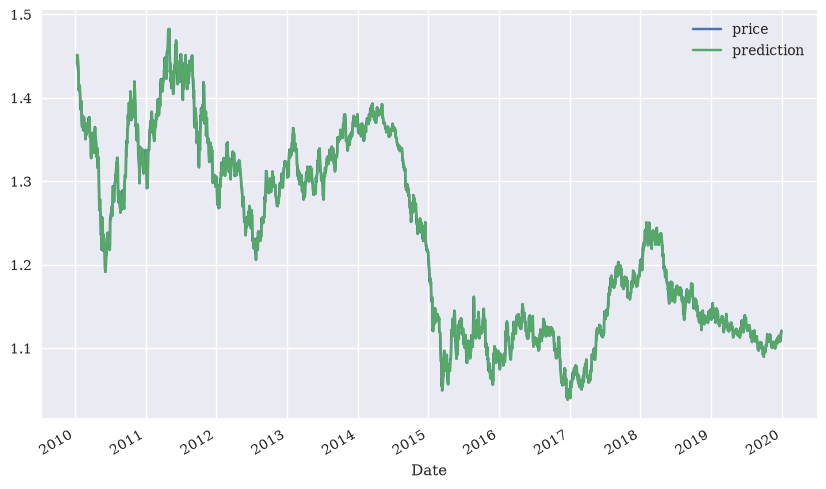

In [39]:
data[['price', 'prediction']].plot(figsize=(10, 6));  # 绘制 price 与 prediction

*图 5-3. 基于线性回归的 EUR/USD 汇率与预测值（五阶滞后）*

把时间窗口缩短再画，两条序列更容易区分。图 5-4 是约三个月窗口：可以看出，对明日汇率的预测大致就是今日汇率，预测序列几乎是把原序列向右平移一个交易日：

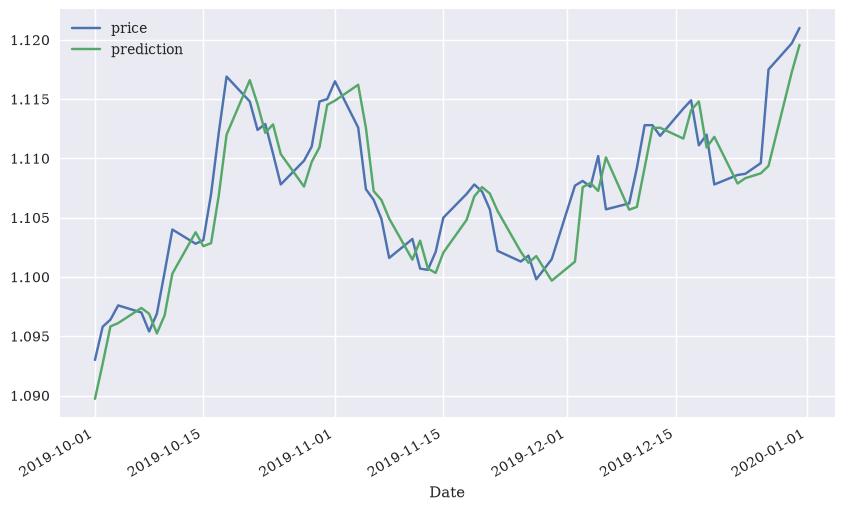

In [40]:
data[['price', 'prediction']].loc['2019-10-1':].plot(figsize=(10, 6));

用历史汇率对 EUR/USD 做线性 OLS 预测，结果支持随机游走假说。数值例子表明，在最小二乘意义下，今日汇率是明日汇率的最佳预测。

*图 5-4. 基于线性回归的 EUR/USD 汇率与预测值（五阶滞后，仅约三个月）*

## 使用对数收益率预测未来收益

到目前为止分析的是绝对价格水平。但对这类统计应用，对数收益率往往更合适，例如更易使序列平稳。对收益数据做线性回归的代码与前面几乎相同。此时相关的不只是今日收益对明日收益的预测，回归结果的性质也完全不同：

In [41]:
data['return'] = np.log(data['price'] / data['price'].shift(1))  # 计算对数收益

In [42]:
data.dropna(inplace=True)  # 删除含 NaN 的行

In [43]:
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data['return'].shift(lag)  # 用收益列构造滞后特征
    cols.append(col)
data.dropna(inplace=True)

In [44]:
data

,price,lag_1,lag_2,lag_3,lag_4,lag_5,prediction,return
Date,,,,,,,,
2010-01-20,1.4101,-0.005858,-0.008309,-0.000551,0.001103,-0.001310,1.429671,-0.013874
2010-01-21,1.4090,-0.013874,-0.005858,-0.008309,-0.000551,0.001103,1.410560,-0.000780
2010-01-22,1.4137,-0.000780,-0.013874,-0.005858,-0.008309,-0.000551,1.408829,0.003330
2010-01-25,1.4150,0.003330,-0.000780,-0.013874,-0.005858,-0.008309,1.414101,0.000919
2010-01-26,1.4073,0.000919,0.003330,-0.000780,-0.013874,-0.005858,1.414653,-0.005457
...,...,...,...,...,...,...,...,...
2019-12-24,1.1087,0.000722,-0.003784,0.000810,-0.003414,0.000628,1.108330,0.000090
2019-12-26,1.1096,0.000090,0.000722,-0.003784,0.000810,-0.003414,1.108738,0.000811
2019-12-27,1.1175,0.000811,0.000090,0.000722,-0.003784,0.000810,1.109368,0.007094


In [45]:
cols

['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']

In [46]:
x, residuals, rank, s  = np.linalg.lstsq(data[cols], data['return'], rcond=None)

In [47]:
x
# Out: array([-0.015689  ,  0.00890227, -0.03634858,  0.01290924, -0.00636023])

array([-0.015689  ,  0.00890227, -0.03634858,  0.01290924, -0.00636023])

下图展示收益与预测值。可以明显看出，线性回归几乎无法在有意义的程度上预测未来收益的幅度：

In [48]:
data['prediction'] = np.dot(data[cols], x)

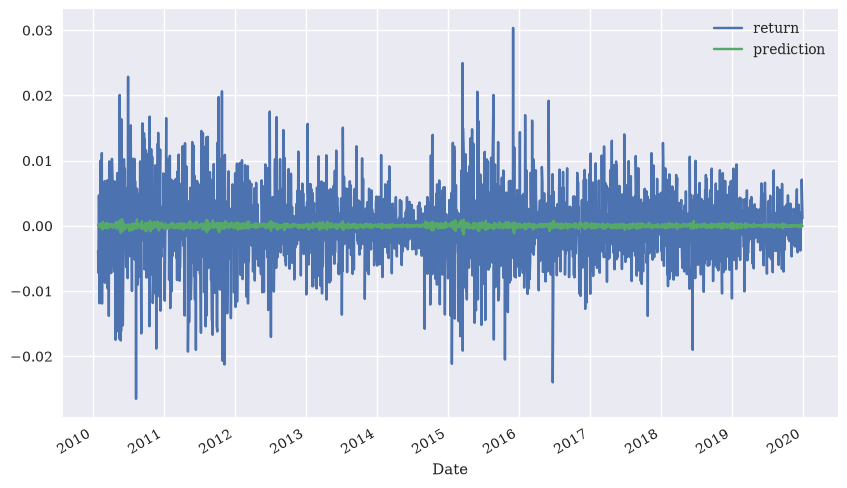

In [49]:
data[['return', 'prediction']].iloc[lags:].plot(figsize=(10, 6));

*图 5-5. 基于线性回归的 EUR/USD 对数收益与预测值（五阶滞后）*

评估预测效果时，不必先盯着收益幅度准不准，更关键的是方向对不对。

做法很直接：把实际市场收益与模型预测收益相乘。

两者同号，乘积为正，说明方向判断正确
两者异号，乘积为负，说明方向判断错误

这个指标关心的是符号一致性，也就是预测收益的正负是否与真实收益一致。

本例中预测正确 1,250 次、错误 1,242 次，命中率约 49.9%，几乎正好 50%：

In [50]:
hits = np.sign(data['return'] * data['prediction']).value_counts()

In [51]:
hits  # 打印两种取值的计数
# Out:
#  1.0    1250
# -1.0    1242
#  0.0      13
# dtype: int64

 1.0    1250
-1.0    1242
 0.0      13
Name: count, dtype: int64

In [52]:
hits.values[0] / sum(hits)  # 命中率 = 正确预测次数 / 全部预测次数
# Out: 0.499001996007984

np.float64(0.499001996007984)

## 从预测未来收益转变为预测未来市场方向

能不能把因变量直接改成对数收益的符号，从而抬高命中率？

理论上，这是把问题从“预测收益大小”简化成“预测收益方向”。实现上也很简单：回归时不用连续收益，而用符号值 1.0 或 -1.0。

这样改之后，命中次数升到 1,301，命中率约 51.9%，大约提高两个百分点。

In [53]:
x, residuals, rank, s   = np.linalg.lstsq(data[cols], np.sign(data['return']),  rcond=None)

In [54]:
x
# Out: array([-5.11938725, -2.24077248, -5.13080606, -3.03753232, -2.14819119])

array([-5.11938725, -2.24077248, -5.13080606, -3.03753232, -2.14819119])

In [55]:
data['prediction'] = np.sign(np.dot(data[cols], x))  # 预测阶段也只保留符号

In [56]:
data['prediction'].value_counts()
# Out:
#  1.0    1300
# -1.0    1205
# Name: prediction, dtype: int64

prediction
 1.0    1300
-1.0    1205
Name: count, dtype: int64

In [57]:
hits = np.sign(data['return'] * data['prediction']).value_counts()

In [58]:
hits
# Out:
#  1.0    1301
# -1.0    1191
#  0.0      13
# dtype: int64

 1.0    1301
-1.0    1191
 0.0      13
Name: count, dtype: int64

In [59]:
hits.values[0] / sum(hits)
# Out: 0.5193612774451097

np.float64(0.5193612774451097)

## 基于回归策略的向量化回测

仅看命中率，还不足以说明这种线性回归交易策略的潜力。众所周知，一段时期内市场最好与最差的约十个交易日，会显著影响投资整体表现。理想情况下，多空交易者会借助择时信号，在最好的日子做多、最差的日子做空。对应到此处：除命中率外，择时质量也很重要。因此，按第 4 章思路做回测，能更好衡量回归预测的价值。

已有数据下，向量化回测只需两行 Python。因为预测值本身已对应多空仓位。图 5-6 显示：在样本内、当前假设下（忽略交易成本等），策略显著跑赢市场：

可参见 *The Tale of 10 Days* 中的讨论。

In [60]:
data['strategy'] = data['prediction'] * data['return']  # 预测值（仓位）乘以市场收益
data.head()

,price,lag_1,lag_2,lag_3,lag_4,lag_5,prediction,return,strategy
Date,,,,,,,,,
2010-01-20,1.4101,-0.005858,-0.008309,-0.000551,0.001103,-0.001310,1.0,-0.013874,-0.013874
2010-01-21,1.4090,-0.013874,-0.005858,-0.008309,-0.000551,0.001103,1.0,-0.000780,-0.000780
2010-01-22,1.4137,-0.000780,-0.013874,-0.005858,-0.008309,-0.000551,1.0,0.003330,0.003330
2010-01-25,1.4150,0.003330,-0.000780,-0.013874,-0.005858,-0.008309,1.0,0.000919,0.000919
2010-01-26,1.4073,0.000919,0.003330,-0.000780,-0.013874,-0.005858,1.0,-0.005457,-0.005457


In [61]:
total_return, total_strategy = np.exp(data[['return', 'strategy']].sum())
print("total_return =", total_return)
print("total_strategy =", total_strategy)

total_return = 0.7840257378654379
total_strategy = 1.6541540397195698


<Axes: xlabel='Date'>

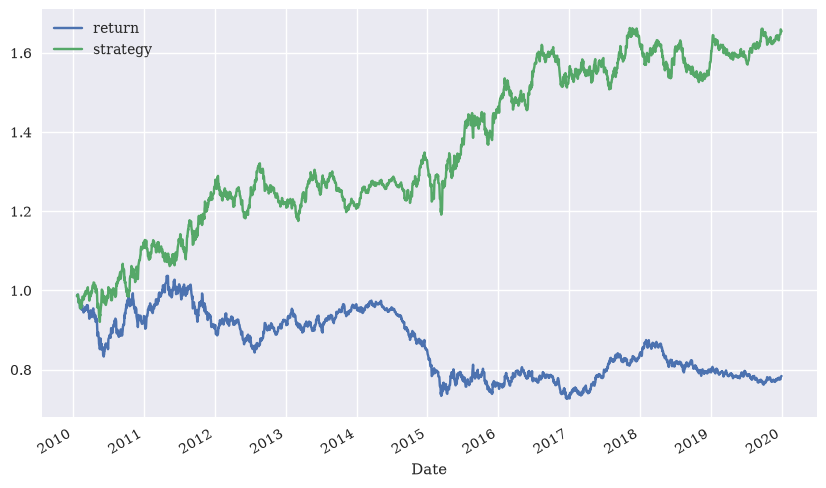

In [62]:
# 绘制标的与策略随时间的总表现（样本内，无交易成本）
curve = data[['return', 'strategy']].dropna().cumsum()
np.exp(curve).plot(figsize=(10, 6))

*图 5-6. EUR/USD 与基于回归策略的总表现（五阶滞后）*

对基于预测的策略而言，命中率只是整体表现的一面；另一面是择时。若能正确预测一段时期最好与最差的交易日，即使命中率低于 50% 也可能跑赢市场。反过来，命中率远高于 50%，若把少数大幅波动方向搞错，仍可能跑输标的。
本例中策略曲线之所以拉开，不只是因为“猜对次数多一点”，更是因为对的日子里，收益幅度贡献更大。

## 泛化

书里第 167 页有一个 Linear Regression Backtesting Class：把第 4 章那种回测写法封装成类，专门对“线性回归交易策略”做向量化回测。

它不只是算收益曲线，还支持：

 - 任意初始资金

 - 按比例扣交易成本

 - 先在一段历史上拟合回归，再在另一段未见过的数据上检验。例如：用 2010–2015 拟合参数，用 2016–2019 做样本外评估。

凡是策略里有“先优化/先拟合”这一步，都该这么测。因为实务里真正重要的是：模型在没见过的新数据上还能不能赚钱。这样能更接近真实可用表现，也减少靠同一批数据又调参又回测带来的数据窥探和过拟合（详见第 111 页）。

图 5-7 显示：五阶滞后的回归策略在该配置下，样本外、计入交易成本之前，也能跑赢 EUR/USD 标的：

In [63]:
import LRVectorBacktester as LR  # 将模块导入为 LR

In [64]:
lrbt = LR.LRVectorBacktester('EUR=', '2010-1-1', '2019-12-31',  10000, 0.0)

In [65]:
aperf, operf = lrbt.run_strategy('2010-1-1', '2019-12-31',  # 训练与评估使用相同数据集
                                 '2010-1-1', '2019-12-31', 
                                 lags=5)

print("aperf = ", aperf) # 策略期末资金，即最后一天的 cstrategy
print("operf = ", operf) # 相对买入持有的超额收益，即最后一天的 cstrategy  − 最后一天的 creturns 

aperf =  17166.53
operf =  9442.42


训练和评估用同一段时期的数据跑一遍的意义在于，使模型等于在“已经见过的数据”上考试一次。这个结果（aperf=17166.53，operf=9442.42）说明：

- 这套策略（回归框架、仓位规则、滞后阶数），在这段历史上是能做出超额的
- 若连样本内都做不出来，后面样本外基本不用指望，所以这个结果有些类似这个策略的能力上限（可行性检查）

In [66]:
aperf, operf = lrbt.run_strategy('2010-1-1', '2017-12-31',  # 训练与评估使用不同数据集
                                 '2018-1-1', '2019-12-31', 
                                 lags=5)

print("aperf = ", aperf) # 策略期末资金，即最后一天的 cstrategy
print("operf = ", operf) # 相对买入持有的超额收益，即最后一天的 cstrategy  − 最后一天的 creturns 

aperf =  10160.86
operf =  791.87


样本内与样本外结果对照表明：样本内表现强，并不意味着样本外依然有效。样本外检验的目的，正在于识别并抑制过拟合。

先在同一数据集上训练与评估，用以确认方法在该历史区间具备基本有效性；再在不同区间上评估，用以检验其对未见数据的泛化能力。前者为对照基准，后者更接近实务可复现的表现。

接下来对 GDX 使用同一套参数与同一时间切分，便于和 EUR= 横向比较。


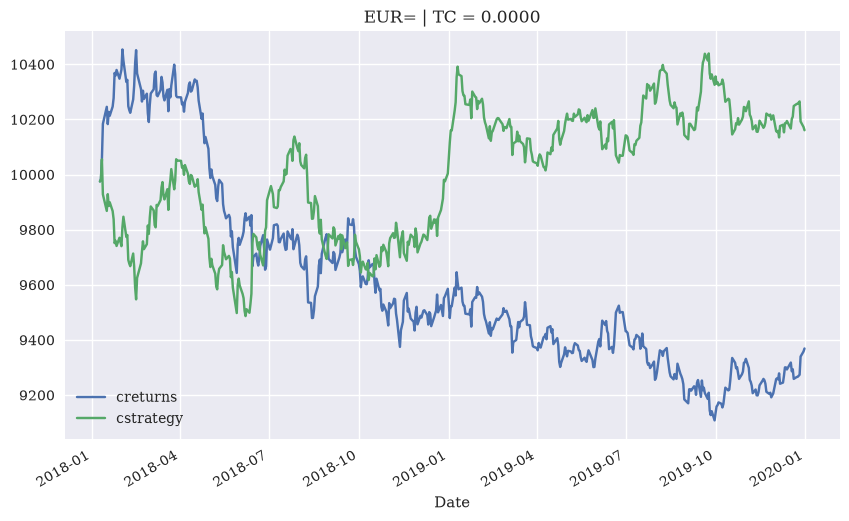

In [67]:
lrbt.plot_results()  # 绘制样本外策略表现并与市场对比

*图 5-7. EUR/USD 与基于回归策略的总表现（五阶滞后，样本外，未计交易成本）*

再看 GDX ETF。为便于与上面的 EUR= 对照，下面使用相同的初始资金、交易成本、滞后期与训练/测试切分：


In [68]:
# 改用 GDX；参数与 EUR= 对齐，便于对照
lrbt = LR.LRVectorBacktester('GDX', '2010-1-1', '2019-12-31', 10000, 0.0)


In [69]:
aperf, operf = lrbt.run_strategy('2010-1-1', '2019-12-31',  # 训练与评估使用相同数据集
                                 '2010-1-1', '2019-12-31',
                                 lags=5)

print("aperf = ", aperf)  # 策略期末资金，即最后一天的 cstrategy
print("operf = ", operf)  # 相对买入持有的超额收益，即最后一天的 cstrategy − 最后一天的 creturns

aperf =  224441.41
operf =  218605.26


In [70]:
aperf, operf = lrbt.run_strategy('2010-1-1', '2017-12-31',  # 训练与评估使用不同数据集
                                 '2018-1-1', '2019-12-31',
                                 lags=5)

print("aperf = ", aperf)  # 策略期末资金，即最后一天的 cstrategy
print("operf = ", operf)  # 相对买入持有的超额收益，即最后一天的 cstrategy − 最后一天的 creturns

aperf =  12156.81
operf =  -345.32


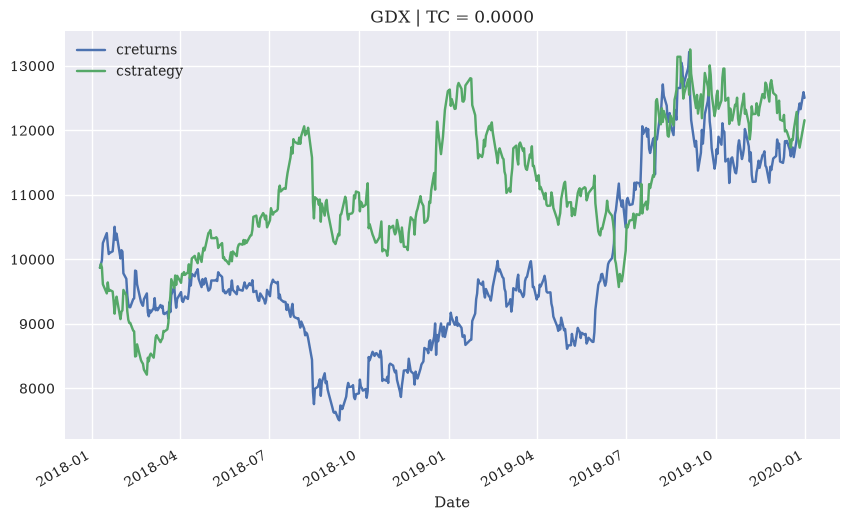

In [71]:
lrbt.plot_results()

*图 5-8. GDX ETF 与基于回归策略的总表现（五阶滞后，样本外，未计交易成本；切分与 EUR= 相同）*

EUR= 样本外仍有小幅超额，GDX 在同一 2018–2019 窗口上超额转为负。书中原 GDX 例子更好看，很大程度来自不同的 `lags`、交易成本与更长的样本外切分，而不是“GDX 天然更能泛化”。
